# Social Post Classification with DistilBERT

BY,

KRITHIK S

In [1]:
import base64
import gzip
import hashlib
import html
import io
import json
import math
import random
import re
import platform
import importlib.metadata
from datetime import datetime, timezone
from pathlib import Path

import numpy as np                    # Numerical arrays and metric inputs.
import pandas as pd                   # CSV loading and data inspection.
import torch                          # Model training and device handling.
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, balanced_accuracy_score
from sklearn.metrics import precision_recall_fscore_support, classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight
import matplotlib.pyplot as plt       # Figures saved alongside the results.
import seaborn as sns                  # Readable distribution and heatmap plots.
from tqdm.auto import tqdm            # Batch progress in Jupyter or Colab.
from IPython.display import display
from transformers import AutoTokenizer, AutoModelForSequenceClassification, DataCollatorWithPadding

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

torch_version_parts = tuple(int(part) for part in torch.__version__.split("+")[0].split(".")[:2])
if torch_version_parts < (2, 6):
    raise RuntimeError("Install PyTorch 2.6 or newer using the official installation selector.")
print("Python:", platform.python_version(), "| PyTorch:", torch.__version__, "| Device:", device)
if device.type == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))
if device.type == "cpu":
    print("CPU training is supported. A GPU is more practical for the complete dataset.")
sns.set_theme(style="whitegrid")

Python: 3.13.15 | PyTorch: 2.11.0+cpu | Device: cpu
CPU training is supported. A GPU is more practical for the complete dataset.


## 2. Data loading and exploration



In [2]:
DATA_PATH ="/content/Labeled_Social_NLP_Training_Data.csv"
TARGET_COLUMN = "sentiment_label"  # Or "topic_category" for a separate run.
source_bytes = Path(DATA_PATH).read_bytes()

data = pd.read_csv(io.BytesIO(source_bytes), dtype="string")
required_columns = ["text_id", "post_text", "sentiment_label", "topic_category"]
if not set(required_columns).issubset(data.columns):
    raise ValueError("The CSV needs: " + ", ".join(required_columns))
if TARGET_COLUMN not in ["sentiment_label", "topic_category"]:
    raise ValueError("Choose sentiment_label or topic_category.")

run_name = datetime.now(timezone.utc).strftime("%Y%m%dT%H%M%S%fZ")
OUTPUT_DIR = Path("transformer_runs") / (TARGET_COLUMN + "_" + run_name)
OUTPUT_DIR.mkdir(parents=True, exist_ok=False)
print("Saving this run to:", OUTPUT_DIR.resolve())
print("Shape:", data.shape)
display(data.head())
display(data.dtypes.to_frame("dtype"))
display(data.isna().sum().to_frame("missing_values"))
display(data.describe(include="all").T)
print("Repeated post texts:", data.post_text.duplicated().sum())
print("Repeated text IDs:", data.text_id.duplicated().sum())

Saving this run to: /content/transformer_runs/sentiment_label_20260918T143315860566Z
Shape: (9000, 4)


,text_id,post_text,sentiment_label,topic_category
0,TXT_00001,some1 come wait in line with me Thursday at 3@...,Negative,Community_Discussion
1,TXT_00002,Mancity strikers Aguero and Dzeko you better t...,Positive,Community_Discussion
2,TXT_00003,Would you like to join us at our annual gala a...,Positive,Community_Discussion
3,TXT_00004,"""Sicily may form grand coalition, Italian UDC ...",Neutral,Community_Discussion
4,TXT_00005,@user @user If the comment was in reference to...,Negative,Community_Discussion


,dtype
text_id,string[python]
post_text,string[python]
sentiment_label,string[python]
topic_category,string[python]


,missing_values
text_id,0
post_text,0
sentiment_label,0
topic_category,0


,count,unique,top,freq
text_id,9000,9000,TXT_00009,1
post_text,9000,7900,I may have just dropped two letter grades of i...,5
sentiment_label,9000,3,Negative,3000
topic_category,9000,4,Community_Discussion,7752


Repeated post texts: 1100
Repeated text IDs: 0


### Inspect label balance and post lengths



,rows
sentiment_label,
Negative,3000
Positive,3000
Neutral,3000


,rows
topic_category,
Community_Discussion,7752
Technical_Issues,815
Feature_Feedback,297
Account_Security,136


,word_count
count,9000.000000
mean,19.472111
std,4.933866
min,4.000000
25%,16.000000
50%,20.000000
75%,23.000000
max,35.000000


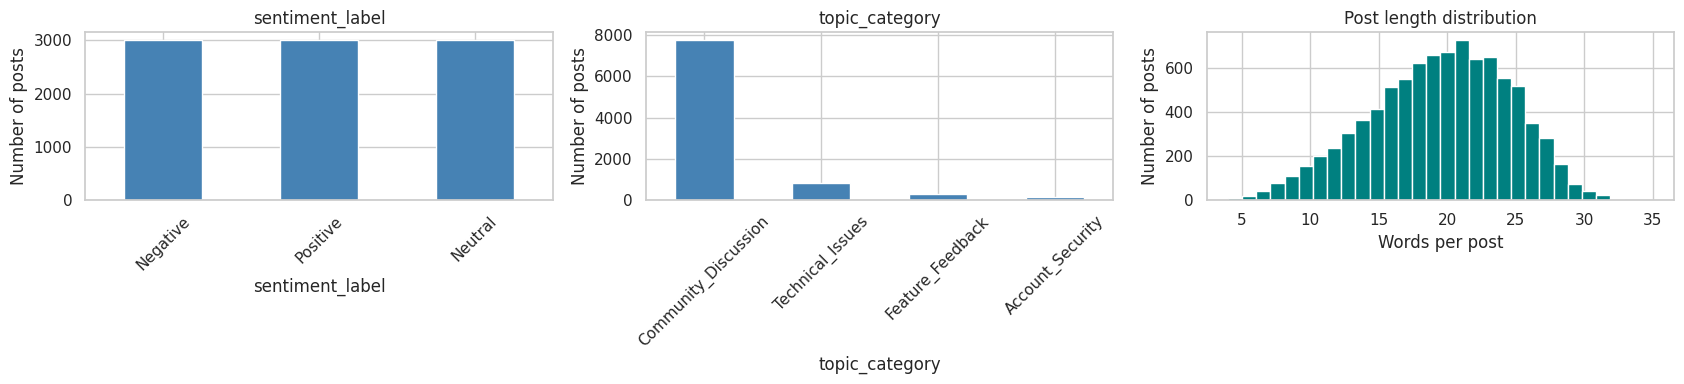

In [3]:
figure, axes = plt.subplots(1, 3, figsize=(17, 4))
for axis, column in zip(axes[:2], ["sentiment_label", "topic_category"]):
    counts = data[column].value_counts(dropna=False)
    display(counts.to_frame("rows"))
    counts.plot.bar(ax=axis, color="steelblue")
    axis.set_title(column)
    axis.set_ylabel("Number of posts")
    axis.tick_params(axis="x", rotation=45)

word_counts = data.post_text.fillna("").str.split().str.len()
axes[2].hist(word_counts, bins=30, color="teal")
axes[2].set_title("Post length distribution")
axes[2].set_xlabel("Words per post")
axes[2].set_ylabel("Number of posts")
display(word_counts.describe().to_frame("word_count"))
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "data_distributions.png", dpi=150, bbox_inches="tight")
plt.show()

## 3. Preprocessing — preserve useful language



In [4]:
def decode_unicode_escape(match):
    number = int(match.group(0)[2:], 16)
    if number > 0x10FFFF:
        return match.group(0)
    return chr(number)


def clean_text(text):
    text = str(text)
    text = re.sub(r"\\u[0-9a-fA-F]{4}|\\U[0-9a-fA-F]{8}", decode_unicode_escape, text)
    # Join escaped UTF-16 surrogate pairs, replacing malformed standalone surrogates.
    text = text.encode("utf-16", errors="surrogatepass").decode("utf-16", errors="replace")
    text = html.unescape(text)
    text = re.sub(r"<[^>]+>", " ", text)
    text = re.sub(r"https?://\S+|www\.\S+", " url ", text)
    text = re.sub(r"(?<!\w)@\w+", " user ", text)
    return re.sub(r"\s+", " ", text).strip().lower()


if data.text_id.isna().any() or data.text_id.str.strip().eq("").any() or data.text_id.duplicated().any():
    raise ValueError("Missing or repeated text IDs need review before splitting.")

working = data.copy()
for column in ["sentiment_label", "topic_category"]:
    working[column] = working[column].str.strip()

missing = working[required_columns].isna().any(axis=1)
for column in required_columns:
    missing = missing | working[column].fillna("").str.strip().eq("")
excluded_parts = [working.loc[missing].assign(exclusion_reason="missing required value")]
working = working.loc[~missing].copy()
working["clean_text"] = working.post_text.map(clean_text)

empty = working.clean_text.eq("")
excluded_parts.append(working.loc[empty].assign(exclusion_reason="empty after cleaning"))
working = working.loc[~empty].copy()

label_counts = working.groupby("clean_text")[TARGET_COLUMN].nunique()
conflicting_texts = label_counts[label_counts > 1].index
conflict_mask = working.clean_text.isin(conflicting_texts)
excluded_parts.append(working.loc[conflict_mask].assign(exclusion_reason="conflicting target labels"))
working = working.loc[~conflict_mask].copy()

duplicates = working.clean_text.duplicated(keep="first")
excluded_parts.append(working.loc[duplicates].assign(exclusion_reason="duplicate cleaned text"))
clean_data = working.loc[~duplicates].reset_index(drop=True)
excluded_data = pd.concat(excluded_parts, ignore_index=True)

assert len(clean_data) + len(excluded_data) == len(data)
assert not clean_data.clean_text.duplicated().any()
assert clean_text(r"I\u2019m NOT happy! &amp; tired") == "i’m not happy! & tired"
clean_data.to_csv(OUTPUT_DIR / "cleaned_data.csv", index=False)
excluded_data.to_csv(OUTPUT_DIR / "excluded_rows.csv", index=False)
print("Original:", len(data), "| Retained:", len(clean_data), "| Excluded:", len(excluded_data))
display(excluded_data.exclusion_reason.value_counts().to_frame("rows"))
display(clean_data[["post_text", "clean_text"]].head())

Original: 9000 | Retained: 7900 | Excluded: 1100


,rows
exclusion_reason,
duplicate cleaned text,1100


,post_text,clean_text
0,some1 come wait in line with me Thursday at 3@...,some1 come wait in line with me thursday at 3@...
1,Mancity strikers Aguero and Dzeko you better t...,mancity strikers aguero and dzeko you better t...
2,Would you like to join us at our annual gala a...,would you like to join us at our annual gala a...
3,"""Sicily may form grand coalition, Italian UDC ...","""sicily may form grand coalition, italian udc ..."
4,@user @user If the comment was in reference to...,user user if the comment was in reference to t...


### Make reproducible training, validation, and test partitions


In [5]:
label_names = ["Negative", "Neutral", "Positive"]
if TARGET_COLUMN == "topic_category":
    label_names = ["Account_Security", "Community_Discussion", "Feature_Feedback", "Technical_Issues"]
if set(clean_data[TARGET_COLUMN]) != set(label_names):
    raise ValueError("The target labels differ from the expected schema; review them first.")
label_to_id = {name: index for index, name in enumerate(label_names)}
id_to_label = {index: name for name, index in label_to_id.items()}
clean_data["labels"] = clean_data[TARGET_COLUMN].map(label_to_id).astype(int)

train_data, temporary_data = train_test_split(
    clean_data, test_size=0.30, stratify=clean_data.labels, random_state=SEED
)
validation_data, test_data = train_test_split(
    temporary_data, test_size=0.50, stratify=temporary_data.labels, random_state=SEED
)
train_data = train_data.reset_index(drop=True)
validation_data = validation_data.reset_index(drop=True)
test_data = test_data.reset_index(drop=True)

split_frames = {"train": train_data, "validation": validation_data, "test": test_data}
for first, second in [("train", "validation"), ("train", "test"), ("validation", "test")]:
    assert set(split_frames[first].clean_text).isdisjoint(split_frames[second].clean_text)
    assert set(split_frames[first].text_id).isdisjoint(split_frames[second].text_id)

manifest_parts = []
for name, frame in split_frames.items():
    assert set(frame.labels) == set(range(len(label_names)))
    manifest_parts.append(frame[["text_id", TARGET_COLUMN, "labels"]].assign(split=name))
    print(name, len(frame))
split_manifest = pd.concat(manifest_parts, ignore_index=True)
split_manifest.to_csv(OUTPUT_DIR / "split_manifest.csv", index=False)
display(pd.crosstab(split_manifest.split, split_manifest[TARGET_COLUMN]))

train 5530
validation 1185
test 1185


sentiment_label,Negative,Neutral,Positive
split,,,
test,365,412,408
train,1701,1924,1905
validation,364,412,409


### Tokenize and create PyTorch batches



In [6]:
MODEL_NAME = "distilbert/distilbert-base-uncased"
MAX_LENGTH = 128
BATCH_SIZE = 16 if device.type == "cuda" else 8

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
training_lengths = tokenizer(train_data.clean_text.tolist(), truncation=False, padding=False)["input_ids"]
truncated_count = sum(len(tokens) > MAX_LENGTH for tokens in training_lengths)
print(f"Training posts longer than {MAX_LENGTH} tokens: {truncated_count}/{len(train_data)}")
del training_lengths


class SocialPostDataset(Dataset):
    def __init__(self, frame):
        self.encodings = tokenizer(
            frame.clean_text.tolist(), truncation=True, max_length=MAX_LENGTH, padding=False
        )
        self.labels = frame.labels.tolist()

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, index):
        item = {}
        for name, values in self.encodings.items():
            item[name] = values[index]
        item["labels"] = self.labels[index]
        return item


padding_collator = DataCollatorWithPadding(tokenizer=tokenizer, return_tensors="pt")
shuffle_generator = torch.Generator().manual_seed(SEED)
train_loader = DataLoader(
    SocialPostDataset(train_data), batch_size=BATCH_SIZE, shuffle=True,
    collate_fn=padding_collator, num_workers=0, generator=shuffle_generator
)
validation_loader = DataLoader(
    SocialPostDataset(validation_data), batch_size=BATCH_SIZE,
    collate_fn=padding_collator, num_workers=0
)
test_loader = DataLoader(
    SocialPostDataset(test_data), batch_size=BATCH_SIZE,
    collate_fn=padding_collator, num_workers=0
)
print("Batch size:", BATCH_SIZE, "| Training batches:", len(train_loader))

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

Training posts longer than 128 tokens: 0/5530
Batch size: 8 | Training batches: 692


## 4. Model selection and configuration



In [7]:
LEARNING_RATE = 2e-5
EPOCHS = 3
WEIGHT_DECAY = 0.01
PATIENCE = 2
USE_CLASS_WEIGHTS = TARGET_COLUMN == "topic_category"

torch.manual_seed(SEED)
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME, num_labels=len(label_names),
    id2label=id_to_label, label2id=label_to_id, use_safetensors=True
).to(device)
BASE_MODEL_REVISION = getattr(model.config, "_commit_hash", None)

class_weights = None
if USE_CLASS_WEIGHTS:
    weights = compute_class_weight(
        class_weight="balanced", classes=np.arange(len(label_names)), y=train_data.labels.to_numpy()
    )
    class_weights = torch.tensor(weights, dtype=torch.float32, device=device)
    print("Training-only class weights:", dict(zip(label_names, weights)))

training_loss_function = torch.nn.CrossEntropyLoss(weight=class_weights)
evaluation_loss_function = torch.nn.CrossEntropyLoss(reduction="sum")
optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
total_steps = EPOCHS * len(train_loader)
warmup_steps = max(1, int(0.10 * total_steps))


def learning_rate_multiplier(step):
    if step < warmup_steps:
        return step / warmup_steps
    return max(0.0, (total_steps - step) / max(1, total_steps - warmup_steps))


scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, learning_rate_multiplier)
print("Optimizer steps:", total_steps, "| Warmup steps:", warmup_steps)
print("Model parameters:", f"{sum(parameter.numel() for parameter in model.parameters()):,}")

model.safetensors: reconstructing file:   0%|          |  0.00B /  268MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert/distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Optimizer steps: 2076 | Warmup steps: 207
Model parameters: 66,955,779


### Define reusable evaluation and metric functions



In [8]:
def calculate_metrics(actual_labels, predicted_labels):
    precision, recall, f1, _ = precision_recall_fscore_support(
        actual_labels, predicted_labels, labels=range(len(label_names)),
        average="macro", zero_division=0
    )
    _, _, weighted_f1, _ = precision_recall_fscore_support(
        actual_labels, predicted_labels, labels=range(len(label_names)),
        average="weighted", zero_division=0
    )
    return {
        "accuracy": float(accuracy_score(actual_labels, predicted_labels)),
        "macro_precision": float(precision), "macro_recall": float(recall),
        "macro_f1": float(f1), "weighted_f1": float(weighted_f1),
        "balanced_accuracy": float(balanced_accuracy_score(actual_labels, predicted_labels)),
    }


def evaluate_model(current_model, data_loader):
    current_model.eval()
    total_loss = 0.0
    actual_labels = []
    logit_batches = []
    with torch.no_grad():
        for batch in data_loader:
            labels = batch["labels"].to(device)
            inputs = {}
            for name, values in batch.items():
                if name != "labels":
                    inputs[name] = values.to(device)
            logits = current_model(**inputs).logits
            total_loss += evaluation_loss_function(logits, labels).item()
            actual_labels.extend(labels.cpu().tolist())
            logit_batches.append(logits.cpu().numpy())
    all_logits = np.concatenate(logit_batches)
    predictions = all_logits.argmax(axis=1)
    metrics = calculate_metrics(actual_labels, predictions)
    metrics["loss"] = total_loss / len(actual_labels)
    return metrics, np.array(actual_labels), predictions, all_logits

## 5. Training loop — save the best validation checkpoint



In [9]:
BEST_MODEL_DIR = OUTPUT_DIR / "best_model"
best_validation_f1 = -1.0
epochs_without_improvement = 0
training_history = []

for epoch in range(1, EPOCHS + 1):
    model.train()
    accumulated_training_loss = 0.0
    batches_seen = 0
    progress = tqdm(train_loader, desc=f"Epoch {epoch}/{EPOCHS}")
    for batch in progress:
        labels = batch["labels"].to(device)
        inputs = {}
        for name, values in batch.items():
            if name != "labels":
                inputs[name] = values.to(device)
        optimizer.zero_grad(set_to_none=True)
        logits = model(**inputs).logits
        loss = training_loss_function(logits, labels)
        if not torch.isfinite(loss):
            raise RuntimeError("Training loss became non-finite; stop and inspect the inputs.")
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        scheduler.step()
        accumulated_training_loss += loss.item()
        batches_seen += 1
        progress.set_postfix(loss=f"{loss.item():.4f}")

    validation_metrics, _, _, _ = evaluate_model(model, validation_loader)
    epoch_record = {
        "epoch": epoch,
        "training_batch_loss": accumulated_training_loss / batches_seen,
        "validation_loss": validation_metrics["loss"],
        "validation_accuracy": validation_metrics["accuracy"],
        "validation_macro_f1": validation_metrics["macro_f1"],
        "learning_rate": optimizer.param_groups[0]["lr"],
    }
    training_history.append(epoch_record)
    pd.DataFrame(training_history).to_csv(OUTPUT_DIR / "training_history.csv", index=False)
    print(epoch_record)

    if validation_metrics["macro_f1"] > best_validation_f1:
        best_validation_f1 = validation_metrics["macro_f1"]
        epochs_without_improvement = 0
        model.save_pretrained(BEST_MODEL_DIR, safe_serialization=True)
        tokenizer.save_pretrained(BEST_MODEL_DIR)
        (OUTPUT_DIR / "best_validation.json").write_text(json.dumps(epoch_record, indent=2))
        print("Saved a better validation checkpoint.")
    else:
        epochs_without_improvement += 1
        if epochs_without_improvement >= PATIENCE:
            print("Early stopping: validation macro F1 has stopped improving.")
            break

Epoch 1/3:   0%|          | 0/692 [00:00<?, ?it/s]

{'epoch': 1, 'training_batch_loss': 0.8488726657250024, 'validation_loss': 0.7433615535497665, 'validation_accuracy': 0.6734177215189874, 'validation_macro_f1': 0.6724954612972437, 'learning_rate': 1.4810058855002676e-05}


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saved a better validation checkpoint.


Epoch 2/3:   0%|          | 0/692 [00:00<?, ?it/s]

...

Saved a better validation checkpoint.


Epoch 3/3:   0%|          | 0/692 [00:00<?, ?it/s]

{'epoch': 3, 'training_batch_loss': 0.37586201900465555, 'validation_loss': 0.8657143329887136, 'validation_accuracy': 0.6928270042194092, 'validation_macro_f1': 0.6936184687238488, 'learning_rate': 0.0}


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saved a better validation checkpoint.


### Track losses and validation performance


,epoch,training_batch_loss,validation_loss,validation_accuracy,validation_macro_f1,learning_rate
0,1,0.848873,0.743362,0.673418,0.672495,0.000015
1,2,0.563119,0.789264,0.682700,0.686547,0.000007
2,3,0.375862,0.865714,0.692827,0.693618,0.000000


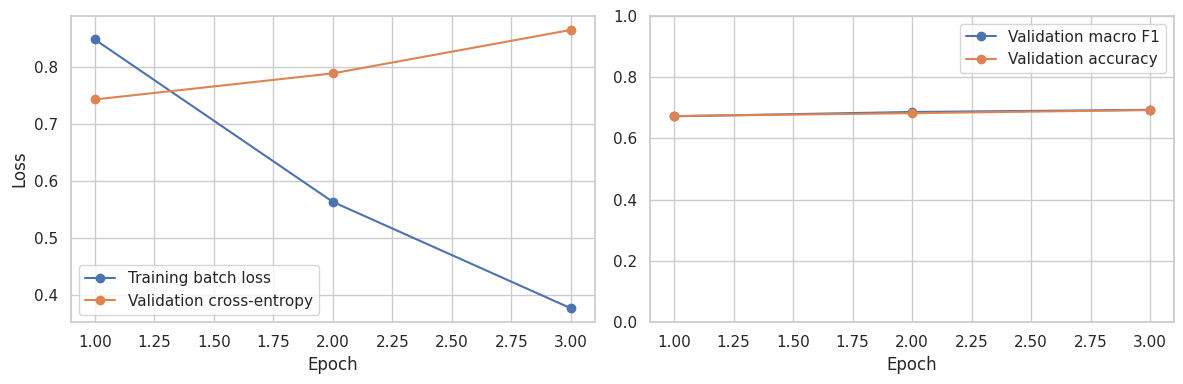

In [10]:
history = pd.DataFrame(training_history)
display(history)
figure, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history.epoch, history.training_batch_loss, marker="o", label="Training batch loss")
axes[0].plot(history.epoch, history.validation_loss, marker="o", label="Validation cross-entropy")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()
axes[1].plot(history.epoch, history.validation_macro_f1, marker="o", label="Validation macro F1")
axes[1].plot(history.epoch, history.validation_accuracy, marker="o", label="Validation accuracy")
axes[1].set_xlabel("Epoch")
axes[1].set_ylim(0, 1)
axes[1].legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "training_curves.png", dpi=150)
plt.show()

## 6. Evaluation and results — selected model on held-out rows



Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

,accuracy,macro_precision,macro_recall,macro_f1,weighted_f1,balanced_accuracy,loss
DistilBERT,0.697046,0.697495,0.700035,0.698615,0.696142,0.700035,0.850874
Majority baseline,0.347679,0.115893,0.333333,0.171989,0.179391,0.333333,NaN


,precision,recall,f1-score,support
Negative,0.744063,0.772603,0.758065,365.000000
Neutral,0.615578,0.594660,0.604938,412.000000
Positive,0.732843,0.732843,0.732843,408.000000
accuracy,0.697046,0.697046,0.697046,0.697046
macro avg,0.697495,0.700035,0.698615,1185.000000
weighted avg,0.695528,0.697046,0.696142,1185.000000


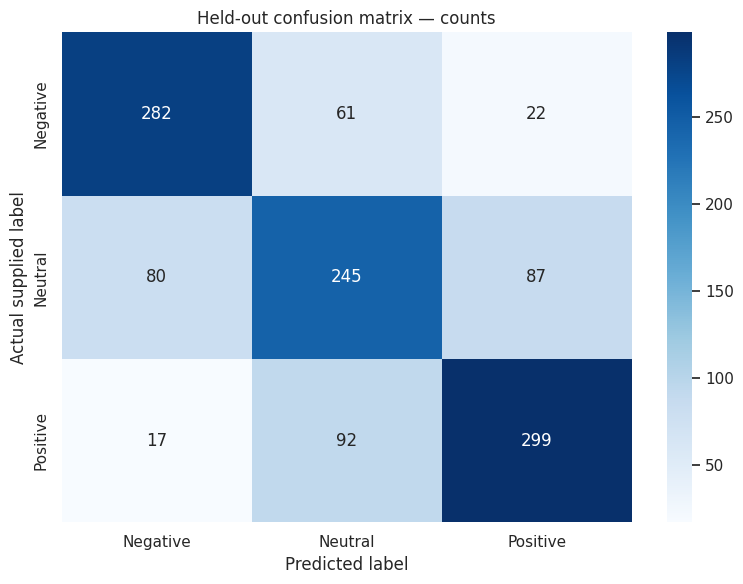

In [11]:
# Release training-only state before loading another model copy onto the device.
del optimizer, scheduler, model
if device.type == "cuda":
    torch.cuda.empty_cache()
model = AutoModelForSequenceClassification.from_pretrained(BEST_MODEL_DIR).to(device)
test_metrics, actual_labels, predicted_labels, test_logits = evaluate_model(model, test_loader)
majority_label = int(train_data.labels.mode().iloc[0])
baseline_predictions = np.full(len(test_data), majority_label)
baseline_metrics = calculate_metrics(actual_labels, baseline_predictions)
display(pd.DataFrame([test_metrics, baseline_metrics], index=["DistilBERT", "Majority baseline"]))

class_report = classification_report(
    actual_labels, predicted_labels, labels=range(len(label_names)),
    target_names=label_names, output_dict=True, zero_division=0
)
class_report_table = pd.DataFrame(class_report).T
display(class_report_table)
class_report_table.to_csv(OUTPUT_DIR / "classification_report.csv")
(OUTPUT_DIR / "test_metrics.json").write_text(json.dumps(test_metrics, indent=2))
(OUTPUT_DIR / "baseline_metrics.json").write_text(json.dumps(baseline_metrics, indent=2))

matrix = confusion_matrix(actual_labels, predicted_labels, labels=range(len(label_names)))
assert matrix.sum() == len(test_data)
pd.DataFrame(matrix, index=label_names, columns=label_names).to_csv(
    OUTPUT_DIR / "confusion_matrix.csv", index_label="actual_label"
)
plt.figure(figsize=(8, 6))
sns.heatmap(matrix, annot=True, fmt="d", cmap="Blues", xticklabels=label_names, yticklabels=label_names)
plt.xlabel("Predicted label")
plt.ylabel("Actual supplied label")
plt.title("Held-out confusion matrix — counts")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

### Inspect correct predictions and mistakes



In [12]:
probabilities = torch.softmax(torch.tensor(test_logits), dim=1).numpy()
results = test_data[["text_id", "post_text", "clean_text", TARGET_COLUMN]].copy()
results["predicted_label"] = [id_to_label[int(value)] for value in predicted_labels]
results["correct"] = actual_labels == predicted_labels
results["uncalibrated_top_score"] = probabilities.max(axis=1)
results.to_csv(OUTPUT_DIR / "test_predictions.csv", index=False)
errors = results.loc[~results.correct].copy()
errors.to_csv(OUTPUT_DIR / "errors.csv", index=False)

for correct, title in [(True, "Correct examples"), (False, "Incorrect examples")]:
    subset = results.loc[results.correct == correct]
    print(title, "—", len(subset), "rows")
    if len(subset):
        with pd.option_context("display.max_colwidth", 180):
            display(subset.sample(n=min(5, len(subset)), random_state=SEED))

if len(errors):
    print("Most common error directions:")
    display(errors.groupby([TARGET_COLUMN, "predicted_label"]).size().sort_values(ascending=False).head(10))
print("Review questions: Is the meaning ambiguous? Is context missing? Does the supplied label fit?")
print("Record observations without treating model predictions as replacement ground truth.")

Correct examples — 826 rows


,text_id,post_text,clean_text,sentiment_label,predicted_label,correct,uncalibrated_top_score
913,TXT_02775,"""Listening to the liverpudlian accent on the tv, actually can't wait to pick it up in September if I make it to uni #ohyes ;)""","""listening to the liverpudlian accent on the tv, actually can't wait to pick it up in september if i make it to uni #ohyes ;)""",Positive,Positive,True,0.981108
249,TXT_01634,I may need a co-owner but she has to be good in english\u002c and to post a lot of Lou\u002c Lux\u002c Tom\u002c etc.. pics ! :),"i may need a co-owner but she has to be good in english, and to post a lot of lou, lux, tom, etc.. pics ! :)",Positive,Positive,True,0.823294
97,TXT_04798,I think I may actually be whipping through the Gilmore Girls series on Netflix too quickly... I'm gonna have to start over again!,i think i may actually be whipping through the gilmore girls series on netflix too quickly... i'm gonna have to start over again!,Positive,Positive,True,0.913778
238,TXT_02181,This mess is coming towards us tomorrow. SPC has a slight risk out for tomorrow\u002c and we\u2019ll know more about what it...,"this mess is coming towards us tomorrow. spc has a slight risk out for tomorrow, and we’ll know more about what it...",Negative,Negative,True,0.969108
388,TXT_01890,"Best of luck to the kerry minors tomorrow , going for 4 in a row, would be a great achievement that shouldn't be overshadowed by football!","best of luck to the kerry minors tomorrow , going for 4 in a row, would be a great achievement that shouldn't be overshadowed by football!",Positive,Positive,True,0.986164


Incorrect examples — 359 rows


,text_id,post_text,clean_text,sentiment_label,predicted_label,correct,uncalibrated_top_score
756,TXT_05394,Unplanned 6th Day of Eid with Bestie! #Eid2015,unplanned 6th day of eid with bestie! #eid2015,Neutral,Positive,False,0.727113
142,TXT_06654,@user are u going to digi tomorrow,user are u going to digi tomorrow,Positive,Neutral,False,0.935630
989,TXT_08699,"""David Bowie: """"Blackstar"""": There is a star in our universe called KIC 8462852 that may or may not be the hub of...","""david bowie: """"blackstar"""": there is a star in our universe called kic 8462852 that may or may not be the hub of...",Positive,Neutral,False,0.965551
1031,TXT_01774,iPhone 6S launches tomorrow. As does the Mahindra TUV300. Too tired to care. All the best #kthxbye,iphone 6s launches tomorrow. as does the mahindra tuv300. too tired to care. all the best #kthxbye,Neutral,Positive,False,0.977013
185,TXT_06248,21st of August and still wondering where Zayn is I hope he's okay,21st of august and still wondering where zayn is i hope he's okay,Neutral,Positive,False,0.902097


Most common error directions:


sentiment_label  predicted_label
Positive         Neutral            92
Neutral          Positive           87
                 Negative           80
Negative         Neutral            61
                 Positive           22
Positive         Negative           17
dtype: int64

Review questions: Is the meaning ambiguous? Is context missing? Does the supplied label fit?
Record observations without treating model predictions as replacement ground truth.


## 7. Inference and demonstration — save, reload, and predict



In [13]:
versions = {}
for package in ["torch", "transformers", "pandas", "numpy", "scikit-learn", "matplotlib", "seaborn"]:
    versions[package] = importlib.metadata.version(package)

preprocessing_source = "import re\nimport html\n\n"
# Store the exact function definitions from their notebook cell for later reuse.
import inspect
try:
    preprocessing_source += inspect.getsource(decode_unicode_escape) + "\n" + inspect.getsource(clean_text)
except (OSError, TypeError):
    # IPython retains cell source even when inspect cannot resolve a cell's filename.
    preprocessing_cell = None
    for cell_source in get_ipython().history_manager.input_hist_raw:
        if cell_source.lstrip().startswith("def decode_unicode_escape("):
            preprocessing_cell = cell_source
    if preprocessing_cell is None:
        raise RuntimeError("Rerun the preprocessing cell before saving its source.")
    preprocessing_source += preprocessing_cell.split("if data.text_id.isna()")[0]
(BEST_MODEL_DIR / "preprocessing.py").write_text(preprocessing_source, encoding="utf-8")

metadata = {
    "target_column": TARGET_COLUMN, "label_to_id": label_to_id,
    "model_name": MODEL_NAME, "base_model_revision": BASE_MODEL_REVISION,
    "source_sha256": hashlib.sha256(source_bytes).hexdigest(),
    "seed": SEED, "max_length": MAX_LENGTH, "batch_size": BATCH_SIZE,
    "learning_rate": LEARNING_RATE, "max_epochs": EPOCHS, "weight_decay": WEIGHT_DECAY,
    "warmup_steps": warmup_steps, "patience": PATIENCE, "class_weighted_loss": USE_CLASS_WEIGHTS,
    "split_sizes": {name: len(frame) for name, frame in split_frames.items()},
    "versions": versions, "python": platform.python_version(), "device": str(device),
    "evaluation_note": "Follow-up development experiment on previously inspected data; not a fresh external test.",
}
(BEST_MODEL_DIR / "run_metadata.json").write_text(json.dumps(metadata, indent=2), encoding="utf-8")
(OUTPUT_DIR / "run_metadata.json").write_text(json.dumps(metadata, indent=2), encoding="utf-8")
print("Saved model and inference files:", BEST_MODEL_DIR.resolve())

Saved model and inference files: /content/transformer_runs/sentiment_label_20260918T143315860566Z/best_model


### Load the saved folder and classify new posts



In [14]:
import importlib.util

saved_metadata = json.loads((BEST_MODEL_DIR / "run_metadata.json").read_text())
module_spec = importlib.util.spec_from_file_location("saved_preprocessing", BEST_MODEL_DIR / "preprocessing.py")
saved_preprocessing = importlib.util.module_from_spec(module_spec)
module_spec.loader.exec_module(saved_preprocessing)
inference_tokenizer = AutoTokenizer.from_pretrained(BEST_MODEL_DIR, local_files_only=True)
inference_model = AutoModelForSequenceClassification.from_pretrained(
    BEST_MODEL_DIR, local_files_only=True
).to(device)
inference_model.eval()


def predict_posts(texts):
    if not texts or any(not isinstance(text, str) for text in texts):
        raise ValueError("Provide a nonempty list of text strings.")
    cleaned_texts = [saved_preprocessing.clean_text(text) for text in texts]
    if any(not text for text in cleaned_texts):
        raise ValueError("At least one text is empty after cleaning.")
    encoded_inputs = inference_tokenizer(
        cleaned_texts, padding=True, truncation=True,
        max_length=saved_metadata["max_length"], return_tensors="pt"
    ).to(device)
    with torch.no_grad():
        scores = torch.softmax(inference_model(**encoded_inputs).logits, dim=1)
    predicted_ids = scores.argmax(dim=1).cpu().tolist()
    rows = []
    for index, text in enumerate(texts):
        rows.append({
            "text": text,
            "predicted_label": inference_model.config.id2label[predicted_ids[index]],
            "uncalibrated_top_score": float(scores[index].max().cpu()),
        })
    return pd.DataFrame(rows)


reload_check = predict_posts(test_data.post_text.head(5).tolist())
assert reload_check.predicted_label.tolist() == results.predicted_label.head(5).tolist()
print("Reloaded-model prediction check passed.")
examples = [
    "I love the new update. It makes everything easier!",
    "The app keeps crashing and I cannot log in.",
    "The update is scheduled for Monday.",
]
display(predict_posts(examples))

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

Reloaded-model prediction check passed.


,text,predicted_label,uncalibrated_top_score
0,I love the new update. It makes everything eas...,Positive,0.986371
1,The app keeps crashing and I cannot log in.,Negative,0.941724
2,The update is scheduled for Monday.,Neutral,0.964707
